In [1]:
file = "/global/cfs/cdirs/m3246/gregork/checkpoints/Train_Regress_E_available3_no_muon_Linear_HuberLoss_20260221_033035/train_results/outputs_best_model_minerva_1A_0.npz"

In [5]:
import numpy as np

result = np.load(file)

ytrue = result["pid"]
ypred = result["prediction"]

/tmp/ipykernel_374204/1727128233.py:3: RuntimeWarning: divide by zero encountered in divide
  ax.hist(ypred/ytrue, bins=np.linspace(0, 2, 100))


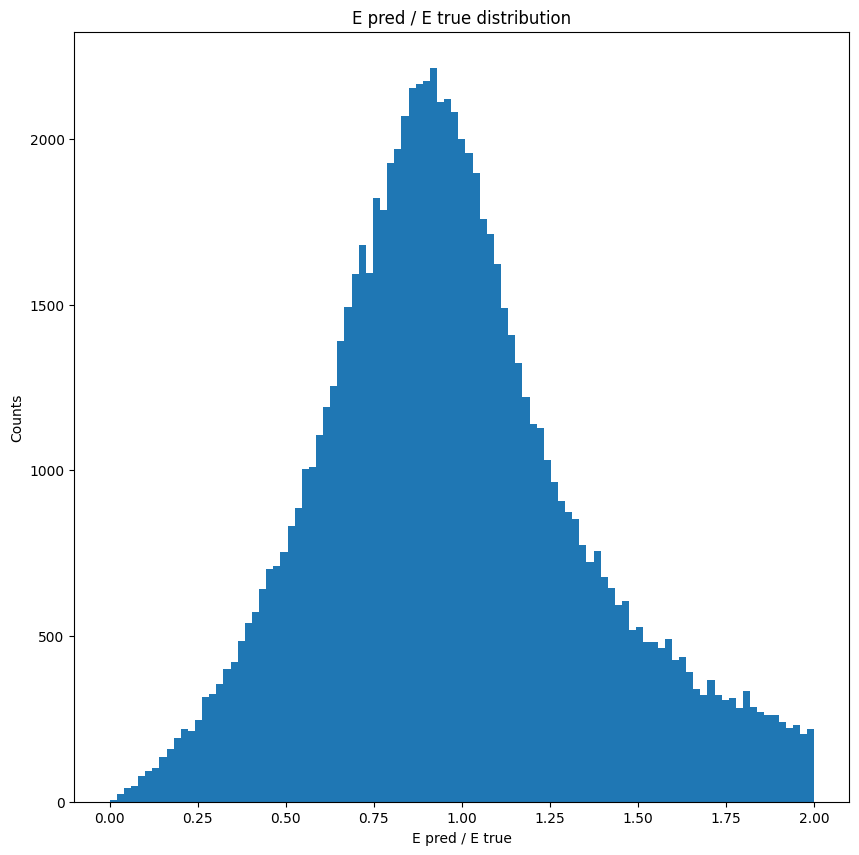

In [12]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.hist(ypred/ytrue, bins=np.linspace(0, 2, 100))
ax.set_xlabel("E pred / E true")
ax.set_ylabel("Counts")
ax.set_title("E pred / E true distribution")
plt.show()


In [30]:
energy_bins = [0, 1, 2, 5, 10, 20]
# for each E true bin, compute median of ypred/ytrue
for i in range(len(energy_bins) - 1):
    low = energy_bins[i]
    high = energy_bins[i+1]
    mask = (ytrue >= low) & (ytrue < high)
    print(f"E true bin {low} to {high}: {np.median(ypred[mask]/ytrue[mask])}")


E true bin 0 to 1: 1.3860324621200562
E true bin 1 to 2: 0.979164719581604
E true bin 2 to 5: 0.9164294004440308
E true bin 5 to 10: 0.868244469165802
E true bin 10 to 20: 0.8571076989173889


/tmp/ipykernel_374204/2087734417.py:7: RuntimeWarning: divide by zero encountered in divide
  print(f"E true bin {low} to {high}: {np.median(ypred[mask]/ytrue[mask])}")


In [62]:
import torch
def relative_huber_loss(Epred, Etrue, delta=0.1, eps=0.1, reduce=False):
    r = (Epred - Etrue) / (Etrue + eps)
    abs_r = torch.abs(r)

    quadratic = 0.5 * r**2
    linear = delta * (abs_r - 0.5 * delta)
    if reduce:
        loss = torch.where(abs_r <= delta, quadratic, linear)
        return loss.mean()
    else:
        return torch.where(abs_r <= delta, quadratic, linear)


In [63]:
losses = relative_huber_loss(torch.tensor(ypred), torch.tensor(ytrue), reduce=False)
losses.max()

tensor(9.8080)

In [79]:
np.quantile((ypred/ytrue)[np.isfinite(ypred/ytrue)], 0.5)

/tmp/ipykernel_374204/3521333159.py:1: RuntimeWarning: divide by zero encountered in divide
  np.quantile((ypred/ytrue)[np.isfinite(ypred/ytrue)], 0.5)


np.float32(1.007683)

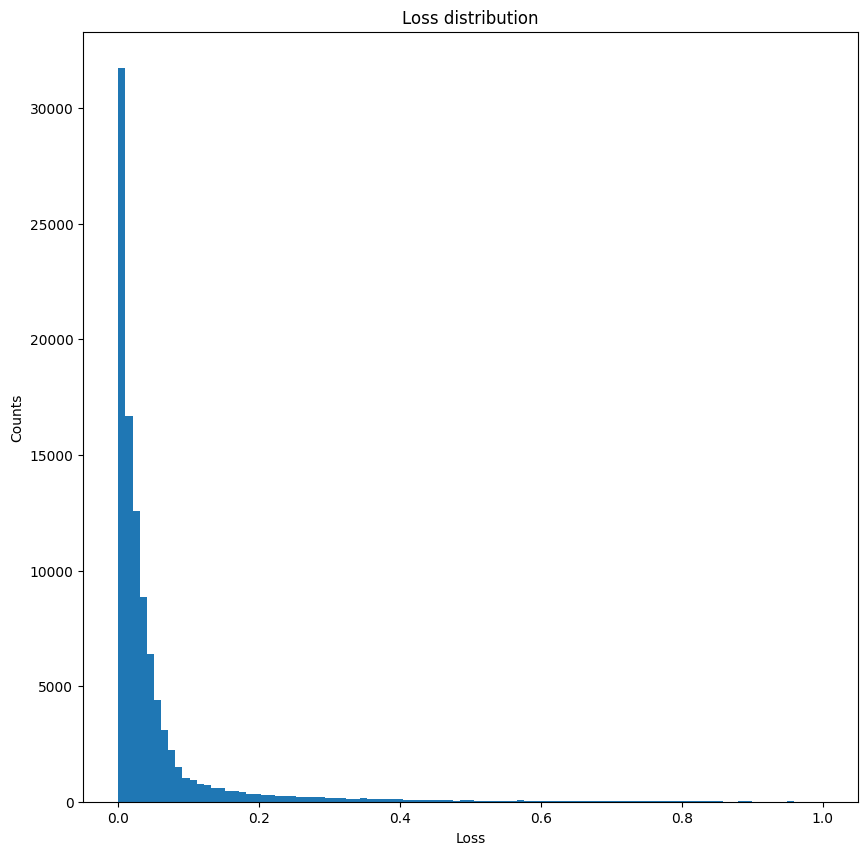

In [72]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.hist(losses, bins=np.linspace(0, 1, 100))
ax.set_xlabel("Loss")
ax.set_ylabel("Counts")
ax.set_title("Loss distribution")
plt.show()


In [17]:
losses

tensor([1.9924e+00, 1.6897e-01, 1.2959e-02,  ..., 8.2564e-01, 7.1033e-04,
        8.1013e-01])

In [21]:
# print ytrue and ypred for top 20 losses
top_losses = losses.argsort()[-200:]
for i in top_losses:
    print(f"ytrue: {ytrue[i]}, ypred: {ypred[i]}, loss: {losses[i]}")


ytrue: 27.336843490600586, ypred: 7.725090503692627, loss: 19.111753463745117
ytrue: 23.241365432739258, ypred: 3.622856378555298, loss: 19.11850929260254
ytrue: 22.85680389404297, ypred: 3.2357168197631836, loss: 19.12108612060547
ytrue: 28.609689712524414, ypred: 8.977934837341309, loss: 19.131755828857422
ytrue: 43.32768249511719, ypred: 23.634923934936523, loss: 19.192758560180664
ytrue: 34.2777214050293, ypred: 14.572286605834961, loss: 19.205434799194336
ytrue: 23.29796028137207, ypred: 3.5893454551696777, loss: 19.208614349365234
ytrue: 62.22201919555664, ypred: 42.507415771484375, loss: 19.214603424072266
ytrue: 28.050426483154297, ypred: 8.29081916809082, loss: 19.259607315063477
ytrue: 52.02313232421875, ypred: 32.230655670166016, loss: 19.292476654052734
ytrue: 22.550247192382812, ypred: 2.7514021396636963, loss: 19.298845291137695
ytrue: 21.2915096282959, ypred: 1.4197341203689575, loss: 19.371774673461914
ytrue: 23.25132942199707, ypred: 3.3411874771118164, loss: 19.410140